In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#Load dataset
data = pd.read_csv("IBM_HR_Analytical.csv")
print("Shape:", data.shape)

Shape: (1470, 33)


In [5]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'AgeGroup',
       'TenureGroup'],
      dtype='object')

##Exploratory Data Analysis

##1.Overall Attrition

In [6]:
#Attrition count
print(data['Attrition'].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


237 employees left the company.

In [7]:
#Attrition rate
attrition_rate = (data['Attrition'].value_counts(normalize=True)*100)
print("The attrition rate is:")
print(attrition_rate)

The attrition rate is:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


Overall employee attrition rate is 16.1%

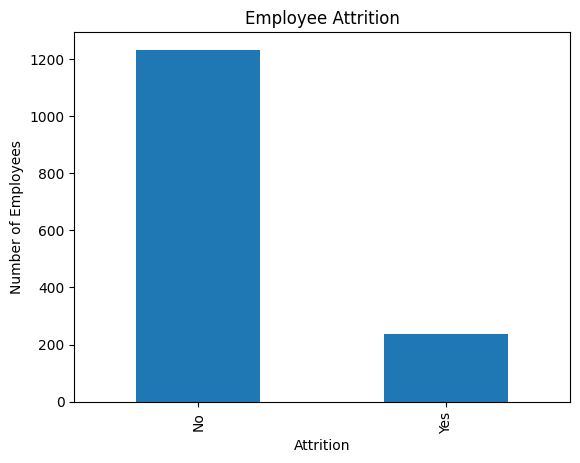

In [8]:
#attrition bar chart
data['Attrition'].value_counts().plot(kind='bar',title='Employee Attrition')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.show()

##2.Factors Affecting Attrition

These factors include Age Group, Tenure Group and Job Role.

In [9]:
#attrition by Age Group
age_attrition = pd.crosstab(
    data['AgeGroup'],
    data['Attrition'],
    normalize='index'
) * 100

print(age_attrition['Yes'])

AgeGroup
25-34       20.216606
35-44       10.099010
45-54       10.204082
55+         15.942029
Under 25    39.175258
Name: Yes, dtype: float64


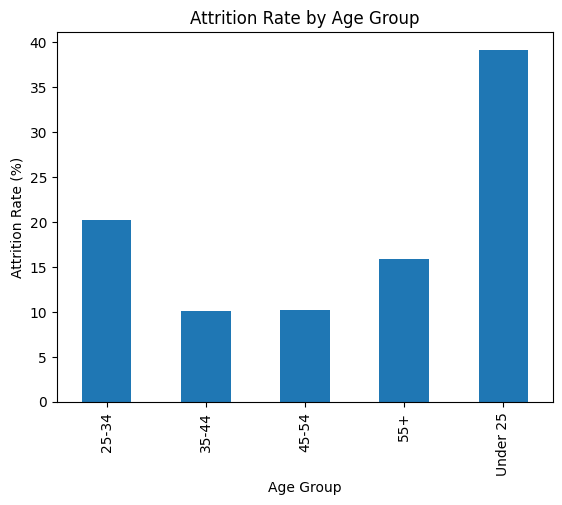

In [10]:
age_attrition['Yes'].plot(
    kind='bar',
    title='Attrition Rate by Age Group'
)

plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.show()

Employees under 25 have the highest attrition rate (39.2%), while employees aged 35-44 have the lowest (10.1%).

In [11]:
#attrition by Tenure Group
tenure_attrition = pd.crosstab(
    data['TenureGroup'],
    data['Attrition'],
    normalize='index'
) * 100

print(tenure_attrition['Yes'])

TenureGroup
0-2     29.824561
10+      8.130081
3-5     13.824885
6-10    12.276786
Name: Yes, dtype: float64


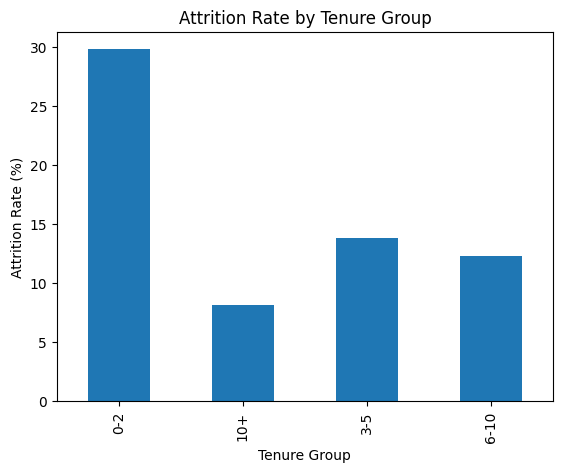

In [12]:
tenure_attrition['Yes'].plot(
    kind='bar',
    title='Attrition Rate by Tenure Group'
)

plt.xlabel('Tenure Group')
plt.ylabel('Attrition Rate (%)')
plt.show()

Employees with 0–2 years at the company have the highest attrition rate (29.8%), while employees with 10+ years have the lowest (8.1%).

In [13]:
#attrition by Job Role
role_attrition = pd.crosstab(
    data['JobRole'],
    data['Attrition'],
    normalize='index'
) * 100

print(role_attrition['Yes'].sort_values(ascending=False))

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Yes, dtype: float64


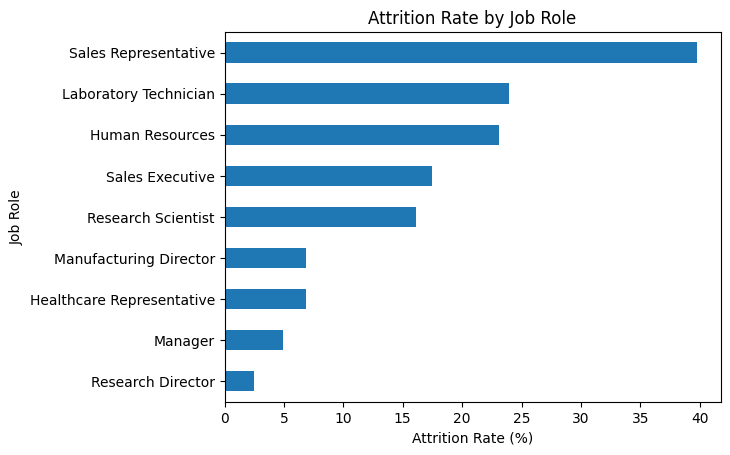

In [14]:
role_attrition['Yes'].sort_values().plot(
    kind='barh',
    title='Attrition Rate by Job Role'
)

plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.show()

Sales Representatives have the highest attrition rate (39.7%) among all job roles.

##3.Work & Satisfaction Factors

These factors include Overtime, Job Satisfaction, Work Life Balance and Business Travel.

In [15]:
#Overtime
overtime_attrition = pd.crosstab(
    data['OverTime'],
    data['Attrition'],
    normalize='index'
) * 100

print(overtime_attrition['Yes'])

OverTime
No     10.436433
Yes    30.528846
Name: Yes, dtype: float64


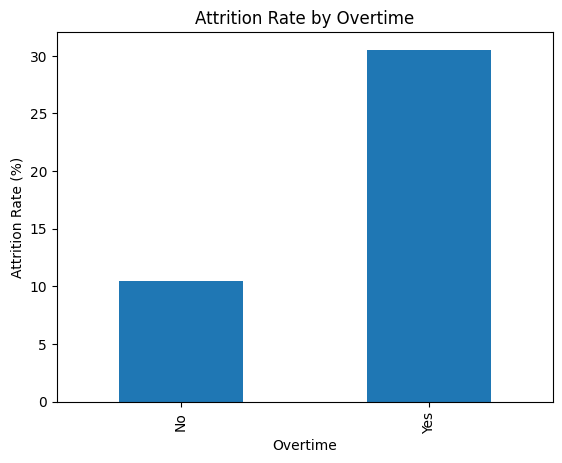

In [16]:
overtime_attrition['Yes'].plot(
    kind='bar',
    title='Attrition Rate by Overtime'
)

plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.show()

Employees who work overtime have a higher attrition rate (30.5%) compared with employees who do not work overtime (10.4%).

In [17]:
#Job Satisfaction
satisfaction_attrition = pd.crosstab(
    data['JobSatisfaction'],
    data['Attrition'],
    normalize='index'
) * 100

print(satisfaction_attrition['Yes'])

JobSatisfaction
1    22.837370
2    16.428571
3    16.515837
4    11.328976
Name: Yes, dtype: float64


Employees with low job satisfaction have the highest attrition rate (22.8%), while employees with very high job satisfaction have the lowest (11.3%).

In [18]:
#Work Life Balance
worklife_attrition = pd.crosstab(
    data['WorkLifeBalance'],
    data['Attrition'],
    normalize='index'
) * 100

print(worklife_attrition['Yes'])

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Yes, dtype: float64


Employees with the lowest work-life balance have the highest attrition rate (31.3%).

In [19]:
#Business Travel
travel_attrition = pd.crosstab(
    data['BusinessTravel'],
    data['Attrition'],
    normalize='index'
) * 100

print(travel_attrition['Yes'])

BusinessTravel
Non-Travel            8.000000
Travel_Frequently    24.909747
Travel_Rarely        14.956855
Name: Yes, dtype: float64


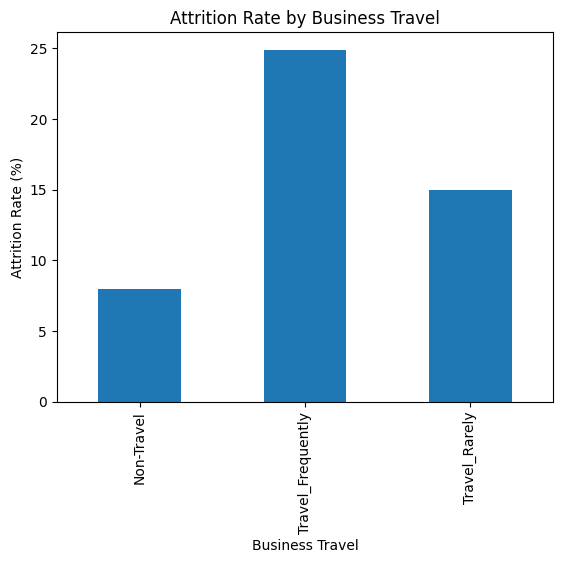

In [21]:
travel_attrition['Yes'].plot(
    kind='bar',
    title='Attrition Rate by Business Travel'
)
plt.xlabel('Business Travel')
plt.ylabel('Attrition Rate (%)')
plt.show()

Employees who travel frequently have the highest attrition rate (24.9%), while non-travel employees have the lowest (8.0%).

##Key EDA Findings

* Employees under 25 have the highest attrition rate(39.2%) among all age groups.
* Employees with 0–2 years at the company have the highest attrition rate (29.8%) among all tenure groups.
* Sales Representatives have the highest attrition rate (39.8%) among job roles.
* Employees who work overtime have a higher attrition rate (30.5%) than those who do not (10.4%).
* Lower job satisfaction and work-life balance are associated with higher attrition rates.
* Employees who travel frequently have a higher attrition rate (24.9%).